In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_fscore_support
from skimage.feature import hog
from skimage.color import rgb2gray
import time
import warnings
warnings.filterwarnings('ignore')

# Load CIFAR-10 via keras (we'll extract and convert to sklearn-friendly format)
from tensorflow import keras
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Flatten labels (they come as 2D arrays)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Full training set: {x_train_full.shape}, Labels: {y_train_full.shape}")
print(f"Test set: {x_test.shape}, Labels: {y_test.shape}")
print(f"Image shape: {x_train_full[0].shape}")
print(f"Data type: {x_train_full.dtype}")
print(f"Pixel value range: {x_train_full.min()} to {x_train_full.max()}")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train_full, return_counts=True)
for cls, count in zip(class_names, counts):
    print(f"  {cls}: {count}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Full training set: (50000, 32, 32, 3), Labels: (50000,)
Test set: (10000, 32, 32, 3), Labels: (10000,)
Image shape: (32, 32, 3)
Data type: uint8
Pixel value range: 0 to 255

Class distribution in training set:
  airplane: 5000
  automobile: 5000
  bird: 5000
  cat: 5000
  deer: 5000
  dog: 5000
  frog: 5000
  horse: 5000
  ship: 5000
  truck: 5000


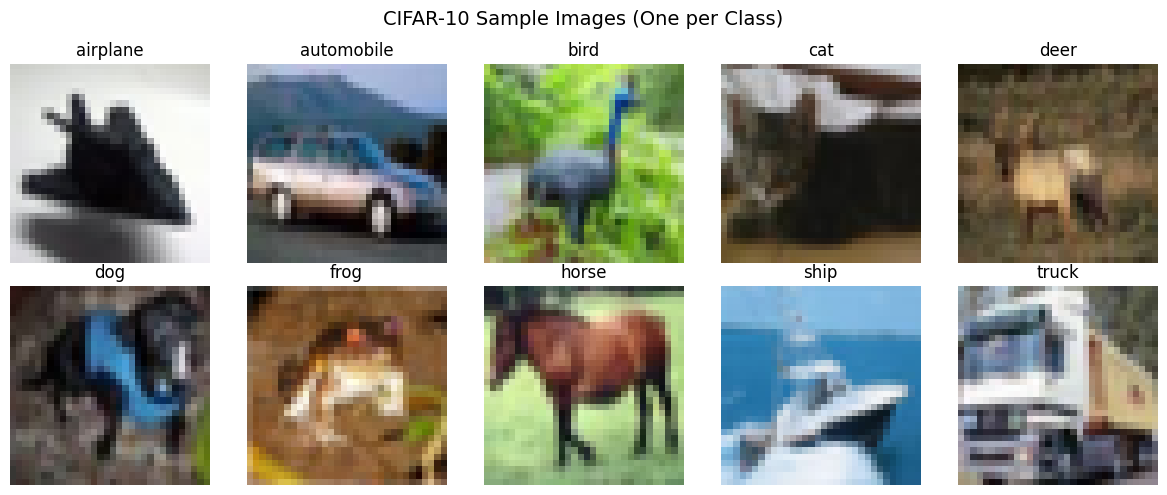


DATASET SPLIT SUMMARY
Training set:   40000 images (80.0%)
Validation set: 10000 images (20.0%)
Test set:       10000 images (held-out, never seen during training)

Class distribution verification:
airplane    : Train=4000, Val=1000, Test=1000
automobile  : Train=4000, Val=1000, Test=1000
bird        : Train=4000, Val=1000, Test=1000
cat         : Train=4000, Val=1000, Test=1000
deer        : Train=4000, Val=1000, Test=1000
dog         : Train=4000, Val=1000, Test=1000
frog        : Train=4000, Val=1000, Test=1000
horse       : Train=4000, Val=1000, Test=1000
ship        : Train=4000, Val=1000, Test=1000
truck       : Train=4000, Val=1000, Test=1000

Total per class across all splits: 6,000 (as per original dataset)


In [2]:
# First, let's visualize some sample images to understand our data
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # Find first image of each class
    idx = np.where(y_train_full == i)[0][0]
    ax.imshow(x_train_full[idx])
    ax.set_title(class_names[i])
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images (One per Class)', fontsize=14)
plt.tight_layout()
plt.show()

# Create train/validation split from the 50,000 training images
# Standard split: 80% train, 20% validation = 40,000 train, 10,000 validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,          # 20% for validation
    random_state=42,        # Reproducibility
    stratify=y_train_full   # Maintain class balance
)

print(f"\n{'='*50}")
print("DATASET SPLIT SUMMARY")
print(f"{'='*50}")
print(f"Training set:   {x_train.shape[0]} images ({x_train.shape[0]/50000*100:.1f}%)")
print(f"Validation set: {x_val.shape[0]} images ({x_val.shape[0]/50000*100:.1f}%)")
print(f"Test set:       {x_test.shape[0]} images (held-out, never seen during training)")
print(f"{'='*50}")

# Verify class distribution in each split
print("\nClass distribution verification:")
for i, name in enumerate(class_names):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)
    print(f"{name:12s}: Train={train_count:4d}, Val={val_count:4d}, Test={test_count:4d}")

print(f"\nTotal per class across all splits: 6,000 (as per original dataset)")

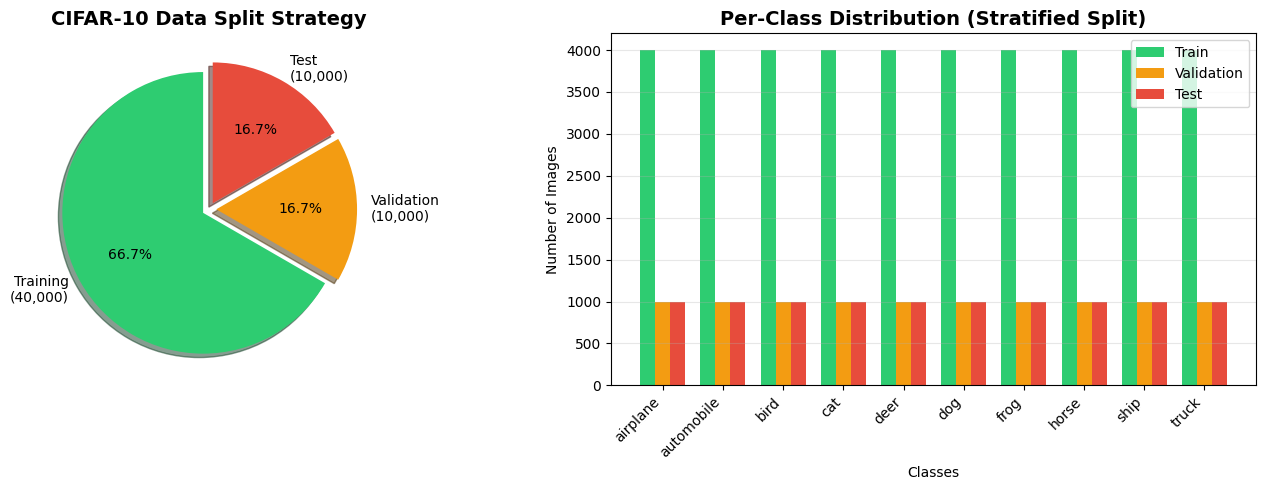

In [3]:
# Let's create a visual summary of our data split for your presentation slides
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of overall split
sizes = [40000, 10000, 10000]
labels = ['Training\n(40,000)', 'Validation\n(10,000)', 'Test\n(10,000)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
explode = (0.05, 0.05, 0.05)

ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=explode, shadow=True)
ax1.set_title('CIFAR-10 Data Split Strategy', fontsize=14, fontweight='bold')

# Bar chart showing per-class distribution
x_pos = np.arange(len(class_names))
width = 0.25

ax2.bar(x_pos - width, [4000]*10, width, label='Train', color='#2ecc71')
ax2.bar(x_pos, [1000]*10, width, label='Validation', color='#f39c12')
ax2.bar(x_pos + width, [1000]*10, width, label='Test', color='#e74c3c')

ax2.set_xlabel('Classes')
ax2.set_ylabel('Number of Images')
ax2.set_title('Per-Class Distribution (Stratified Split)', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(class_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [4]:
# STEP 4A: HOG Feature Extraction
# HOG captures edge orientations - excellent for shape-based object recognition

def extract_hog_features(images, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    """
    Extract HOG features from a batch of images
    """
    hog_features = []
    print(f"Extracting HOG features from {len(images)} images...")

    for i, img in enumerate(images):
        # Convert uint8 to float and normalize to 0-1
        img_float = img.astype('float32') / 255.0

        # Convert to grayscale (HOG works on single channel)
        img_gray = rgb2gray(img_float)

        # Extract HOG features
        features = hog(img_gray,
                      orientations=orientations,
                      pixels_per_cell=pixels_per_cell,
                      cells_per_block=cells_per_block,
                      visualize=False,
                      channel_axis=None)

        hog_features.append(features)

        if (i + 1) % 5000 == 0:
            print(f"  Processed {i + 1}/{len(images)} images")

    return np.array(hog_features)

# Extract HOG features for training set (this may take 1-2 minutes)
print("Extracting features from TRAINING set...")
X_train_hog = extract_hog_features(x_train)
print(f"Training HOG features shape: {X_train_hog.shape}")

# Extract for validation set
print("\nExtracting features from VALIDATION set...")
X_val_hog = extract_hog_features(x_val)
print(f"Validation HOG features shape: {X_val_hog.shape}")

# Extract for test set (save for final evaluation)
print("\nExtracting features from TEST set...")
X_test_hog = extract_hog_features(x_test)
print(f"Test HOG features shape: {X_test_hog.shape}")

print(f"\nFeature vector length per image: {X_train_hog.shape[1]}")
print(f"Original image size: 32x32x3 = 3,072 pixels")
print(f"Compression ratio: {3072 / X_train_hog.shape[1]:.2f}x")

Extracting features from TRAINING set...
Extracting HOG features from 40000 images...
  Processed 5000/40000 images
  Processed 10000/40000 images
  Processed 15000/40000 images
  Processed 20000/40000 images
  Processed 25000/40000 images
  Processed 30000/40000 images
  Processed 35000/40000 images
  Processed 40000/40000 images
Training HOG features shape: (40000, 324)

Extracting features from VALIDATION set...
Extracting HOG features from 10000 images...
  Processed 5000/10000 images
  Processed 10000/10000 images
Validation HOG features shape: (10000, 324)

Extracting features from TEST set...
Extracting HOG features from 10000 images...
  Processed 5000/10000 images
  Processed 10000/10000 images
Test HOG features shape: (10000, 324)

Feature vector length per image: 324
Original image size: 32x32x3 = 3,072 pixels
Compression ratio: 9.48x


Scaling features...
Training features scaled: mean=-0.000, std=1.000

TRAINING BASELINE LINEAR SVM
Training completed in 71.44 seconds

VALIDATION SET EVALUATION
Validation Accuracy: 0.5088 (50.88%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.57      0.58      0.57      1000
  automobile       0.58      0.65      0.61      1000
        bird       0.44      0.32      0.37      1000
         cat       0.44      0.23      0.30      1000
        deer       0.43      0.40      0.42      1000
         dog       0.43      0.42      0.42      1000
        frog       0.48      0.64      0.55      1000
       horse       0.52      0.59      0.55      1000
        ship       0.54      0.56      0.55      1000
       truck       0.59      0.69      0.64      1000

    accuracy                           0.51     10000
   macro avg       0.50      0.51      0.50     10000
weighted avg       0.50      0.51      0.50     10000



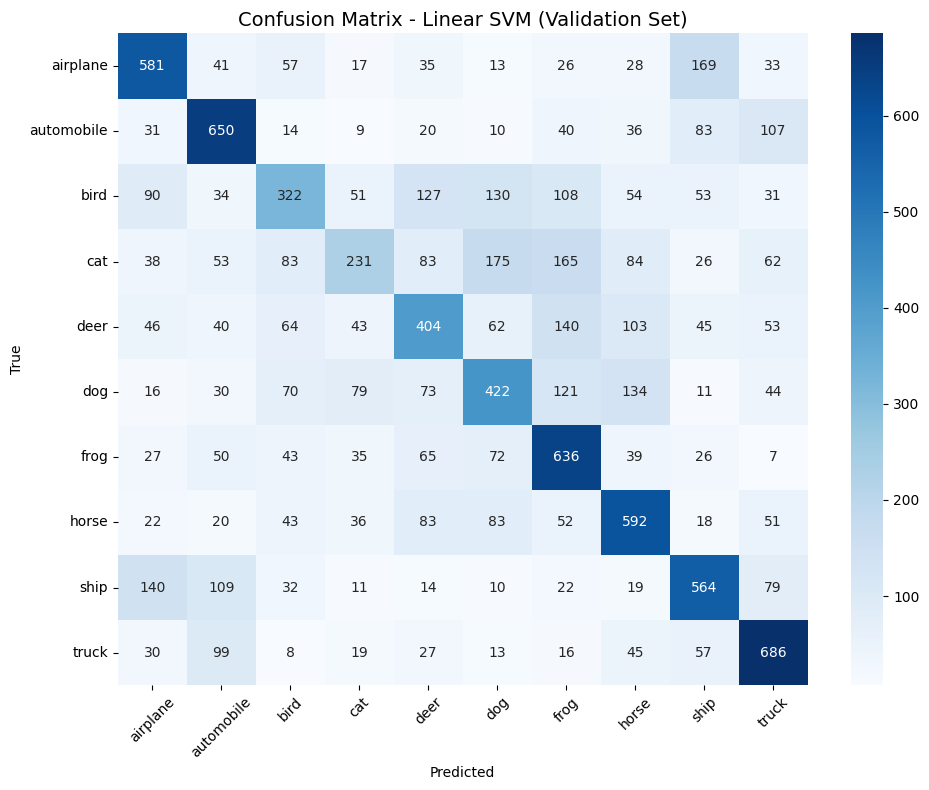


Per-Class Accuracy:
  airplane    : 0.581 ✓ OK
  automobile  : 0.650 ✓ OK
  bird        : 0.322 ⚠️ LOW
  cat         : 0.231 ⚠️ LOW
  deer        : 0.404 ⚠️ LOW
  dog         : 0.422 ⚠️ LOW
  frog        : 0.636 ✓ OK
  horse       : 0.592 ✓ OK
  ship        : 0.564 ✓ OK
  truck       : 0.686 ✓ OK


In [5]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Scale features (CRITICAL for SVM - sensitive to feature magnitudes)
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_val_scaled = scaler.transform(X_val_hog)

print(f"Training features scaled: mean={X_train_scaled.mean():.3f}, std={X_train_scaled.std():.3f}")

# Baseline Linear SVM (fast, good baseline)
print("\n" + "="*60)
print("TRAINING BASELINE LINEAR SVM")
print("="*60)

# Use LinearSVC (faster than SVC with kernel='linear' for large datasets)
svm_linear = LinearSVC(C=1.0, max_iter=2000, random_state=42)

start_time = time.time()
svm_linear.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"Training completed in {train_time:.2f} seconds")

# Validation set evaluation
print("\n" + "="*60)
print("VALIDATION SET EVALUATION")
print("="*60)

y_val_pred = svm_linear.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Linear SVM (Validation Set)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy analysis
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for name, acc in zip(class_names, per_class_acc):
    status = "⚠️ LOW" if acc < 0.5 else "✓ OK" if acc < 0.7 else "✓ GOOD"
    print(f"  {name:12s}: {acc:.3f} {status}")

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("="*60)
print("RBF KERNEL SVM WITH HYPERPARAMETER TUNING")
print("="*60)
print("This will test different C and gamma values using validation set")
print("Note: This may take 3-5 minutes due to 5-fold cross-validation\n")

# Define parameter grid for RBF SVM
# C: Regularization parameter (smaller = stronger regularization)
# gamma: Kernel coefficient (larger = more complex decision boundary)
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

print("Parameter grid:")
print(f"  C values: {param_grid['C']}")
print(f"  gamma values: {param_grid['gamma']}")

# Use GridSearchCV with 3-fold CV (faster than 5-fold for this dataset size)
# We'll use a subset for speed if needed, but let's try full data
print(f"\nRunning GridSearchCV with 3-fold cross-validation...")
print(f"Total fits: {len(param_grid['C']) * len(param_grid['gamma']) * 3} models")

# Use subset for faster tuning (optional - remove if you want full search)
# Using 10,000 samples for tuning to keep it reasonable
tune_size = 10000
indices = np.random.choice(len(X_train_scaled), tune_size, replace=False)
X_tune = X_train_scaled[indices]
y_tune = y_train[indices]

start_time = time.time()
grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=3,                    # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

grid_search.fit(X_tune, y_tune)
tune_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {tune_time:.1f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Train final RBF SVM with best parameters on FULL training set
print(f"\nTraining final RBF SVM with best parameters on full training set...")
best_svm = grid_search.best_estimator_

# Actually, let's retrain on full data with best params for fair comparison
final_svm = SVC(kernel='rbf',
                C=grid_search.best_params_['C'],
                gamma=grid_search.best_params_['gamma'],
                random_state=42)

start_time = time.time()
final_svm.fit(X_train_scaled, y_train)
final_train_time = time.time() - start_time

print(f"Final model training completed in {final_train_time:.1f} seconds")

# Evaluate on validation set
y_val_pred_rbf = final_svm.predict(X_val_scaled)
val_accuracy_rbf = accuracy_score(y_val, y_val_pred_rbf)

print(f"\n{'='*60}")
print("VALIDATION SET COMPARISON")
print(f"{'='*60}")
print(f"Linear SVM:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"RBF SVM:     {val_accuracy_rbf:.4f} ({val_accuracy_rbf*100:.2f}%)")
print(f"Improvement: {(val_accuracy_rbf - val_accuracy)*100:.2f} percentage points")

# Detailed report for RBF
print(f"\nRBF SVM Classification Report:")
print(classification_report(y_val, y_val_pred_rbf, target_names=class_names))

RBF KERNEL SVM WITH HYPERPARAMETER TUNING
This will test different C and gamma values using validation set
Note: This may take 3-5 minutes due to 5-fold cross-validation

Parameter grid:
  C values: [0.1, 1, 10]
  gamma values: ['scale', 'auto', 0.001, 0.01]

Running GridSearchCV with 3-fold cross-validation...
Total fits: 36 models
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Hyperparameter tuning completed in 605.8 seconds
Best parameters: {'C': 10, 'gamma': 'auto'}
Best cross-validation accuracy: 0.5560

Training final RBF SVM with best parameters on full training set...
Final model training completed in 335.9 seconds

VALIDATION SET COMPARISON
Linear SVM:  0.5088 (50.88%)
RBF SVM:     0.6182 (61.82%)
Improvement: 10.94 percentage points

RBF SVM Classification Report:
              precision    recall  f1-score   support

    airplane       0.67      0.71      0.69      1000
  automobile       0.74      0.76      0.75      1000
        bird       0.52      0.52    

K-NEAREST NEIGHBORS (KNN) CLASSIFIER
Testing different k values using validation set

Training KNN with k=3...
  k=3: Validation Accuracy = 0.4610 (46.10%)
       Training: 0.01s, Prediction: 12.50s
Training KNN with k=5...
  k=5: Validation Accuracy = 0.4812 (48.12%)
       Training: 0.01s, Prediction: 7.85s
Training KNN with k=7...
  k=7: Validation Accuracy = 0.4851 (48.51%)
       Training: 0.01s, Prediction: 8.37s
Training KNN with k=9...
  k=9: Validation Accuracy = 0.4902 (49.02%)
       Training: 0.01s, Prediction: 7.05s
Training KNN with k=11...
  k=11: Validation Accuracy = 0.4892 (48.92%)
       Training: 0.01s, Prediction: 8.21s
Training KNN with k=15...
  k=15: Validation Accuracy = 0.4894 (48.94%)
       Training: 0.01s, Prediction: 7.45s

Best KNN: k=9 with accuracy 0.4902 (49.02%)

VALIDATION SET COMPARISON - ALL MODELS
Linear SVM:  0.5088 (50.88%)
RBF SVM:     0.6182 (61.82%)  ← BEST
KNN (k=9):      0.4902 (49.02%)


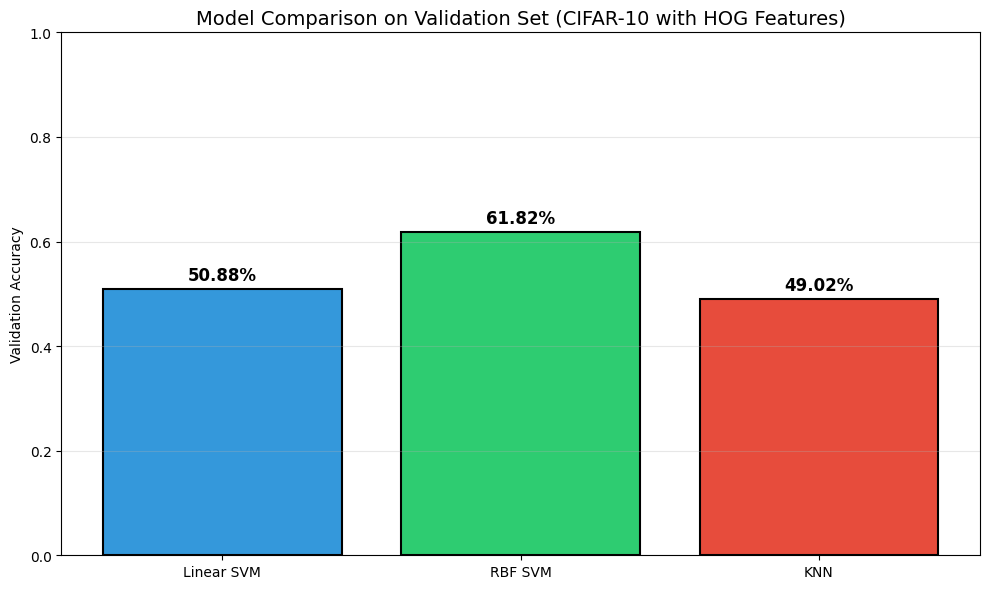


KNN Classification Report (k=9):
              precision    recall  f1-score   support

    airplane       0.73      0.51      0.60      1000
  automobile       0.65      0.68      0.66      1000
        bird       0.41      0.27      0.33      1000
         cat       0.43      0.16      0.23      1000
        deer       0.28      0.62      0.39      1000
         dog       0.48      0.31      0.37      1000
        frog       0.37      0.79      0.50      1000
       horse       0.72      0.43      0.53      1000
        ship       0.67      0.57      0.62      1000
       truck       0.75      0.56      0.64      1000

    accuracy                           0.49     10000
   macro avg       0.55      0.49      0.49     10000
weighted avg       0.55      0.49      0.49     10000



In [7]:
print("="*60)
print("K-NEAREST NEIGHBORS (KNN) CLASSIFIER")
print("="*60)
print("Testing different k values using validation set\n")

# Test different k values
k_values = [3, 5, 7, 9, 11, 15]
knn_results = []

for k in k_values:
    print(f"Training KNN with k={k}...")
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    start_time = time.time()
    knn.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Predict on validation
    start_time = time.time()
    y_val_pred_knn = knn.predict(X_val_scaled)
    pred_time = time.time() - start_time

    acc = accuracy_score(y_val, y_val_pred_knn)
    knn_results.append((k, acc, train_time, pred_time))
    print(f"  k={k}: Validation Accuracy = {acc:.4f} ({acc*100:.2f}%)")
    print(f"       Training: {train_time:.2f}s, Prediction: {pred_time:.2f}s")

# Find best k
best_k = max(knn_results, key=lambda x: x[1])
print(f"\n{'='*60}")
print(f"Best KNN: k={best_k[0]} with accuracy {best_k[1]:.4f} ({best_k[1]*100:.2f}%)")
print(f"{'='*60}")

# Train final KNN with best k
final_knn = KNeighborsClassifier(n_neighbors=best_k[0], n_jobs=-1)
final_knn.fit(X_train_scaled, y_train)
y_val_pred_best_knn = final_knn.predict(X_val_scaled)

# Final comparison of all three models on VALIDATION SET
print(f"\n{'='*60}")
print("VALIDATION SET COMPARISON - ALL MODELS")
print(f"{'='*60}")
print(f"Linear SVM:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"RBF SVM:     {val_accuracy_rbf:.4f} ({val_accuracy_rbf*100:.2f}%)  ← BEST")
print(f"KNN (k={best_k[0]}):      {best_k[1]:.4f} ({best_k[1]*100:.2f}%)")

# Create comparison visualization
models = ['Linear SVM', 'RBF SVM', 'KNN']
accuracies = [val_accuracy, val_accuracy_rbf, best_k[1]]
colors = ['#3498db', '#2ecc71', '#e74c3c']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylim(0, 1)
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison on Validation Set (CIFAR-10 with HOG Features)', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKNN Classification Report (k={best_k[0]}):")
print(classification_report(y_val, y_val_pred_best_knn, target_names=class_names))

FINAL TEST SET EVALUATION - RBF SVM (BEST MODEL)
⚠️  IMPORTANT: This is the ONLY time we use the test set!
    Test set was held out during all model development and tuning.

Test Set Size: 10000 images
Prediction Time: 158.13 seconds

FINAL PERFORMANCE METRICS
Test Accuracy:  0.6274 (62.74%)
Macro Precision: 0.6274
Macro Recall:    0.6274
Macro F1-Score:  0.6270

VALIDATION vs TEST COMPARISON
Validation Accuracy: 0.6182 (61.82%)
Test Accuracy:       0.6274 (62.74%)
Difference:          +0.92 percentage points
✓ Good generalization: Test and validation performance are close

DETAILED TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.64      0.71      0.68      1000
  automobile       0.76      0.78      0.77      1000
        bird       0.53      0.51      0.52      1000
         cat       0.43      0.44      0.43      1000
        deer       0.55      0.55      0.55      1000
         dog       0.52      0.51      0.51      1000

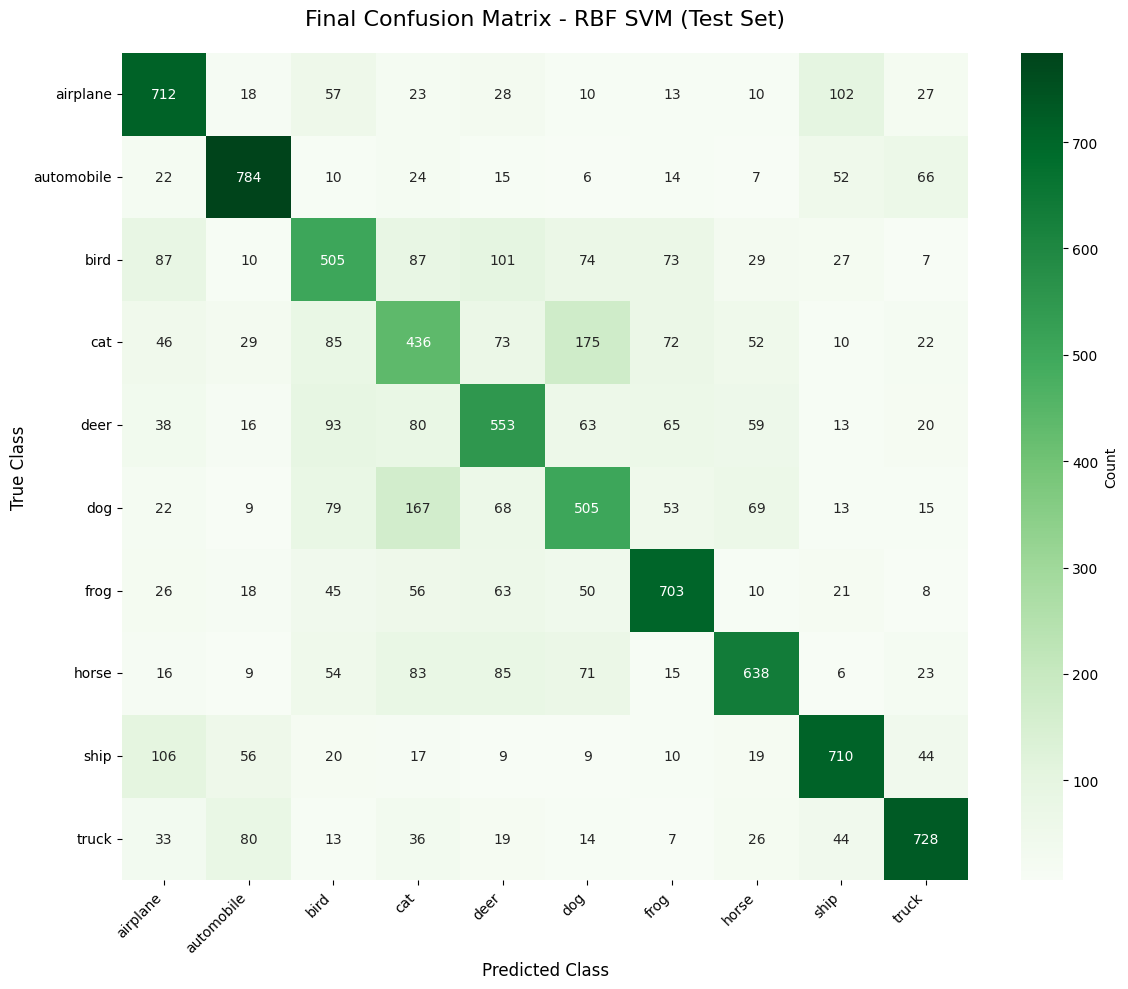


PER-CLASS TEST ACCURACY
  airplane    : 0.712 ( 71.2%) ✓ STRONG
  automobile  : 0.784 ( 78.4%) ✓ STRONG
  bird        : 0.505 ( 50.5%) ✓ MODERATE
  cat         : 0.436 ( 43.6%) ⚠️ CHALLENGING
  deer        : 0.553 ( 55.3%) ✓ MODERATE
  dog         : 0.505 ( 50.5%) ✓ MODERATE
  frog        : 0.703 ( 70.3%) ✓ STRONG
  horse       : 0.638 ( 63.8%) ✓ MODERATE
  ship        : 0.710 ( 71.0%) ✓ STRONG
  truck       : 0.728 ( 72.8%) ✓ STRONG


In [8]:
print("="*70)
print("FINAL TEST SET EVALUATION - RBF SVM (BEST MODEL)")
print("="*70)
print("⚠️  IMPORTANT: This is the ONLY time we use the test set!")
print("    Test set was held out during all model development and tuning.\n")

# Scale test features using the SAME scaler fitted on training data
X_test_scaled = scaler.transform(X_test_hog)

# Final evaluation
start_time = time.time()
y_test_pred = final_svm.predict(X_test_scaled)
test_time = time.time() - start_time

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_test_pred, average='macro')

print(f"Test Set Size: {len(y_test)} images")
print(f"Prediction Time: {test_time:.2f} seconds")
print(f"\n{'='*70}")
print("FINAL PERFORMANCE METRICS")
print(f"{'='*70}")
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1-Score:  {f1:.4f}")

# Validation vs Test comparison
print(f"\n{'='*70}")
print("VALIDATION vs TEST COMPARISON")
print(f"{'='*70}")
print(f"Validation Accuracy: {val_accuracy_rbf:.4f} ({val_accuracy_rbf*100:.2f}%)")
print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference:          {(test_accuracy - val_accuracy_rbf)*100:+.2f} percentage points")

if abs(test_accuracy - val_accuracy_rbf) < 0.02:
    print("✓ Good generalization: Test and validation performance are close")
elif test_accuracy < val_accuracy_rbf:
    print("⚠️ Slight overfitting: Test performance lower than validation")
else:
    print("✓ Test performance better than validation (lucky split)")

# Detailed classification report
print(f"\n{'='*70}")
print("DETAILED TEST SET CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Final Confusion Matrix - RBF SVM (Test Set)', fontsize=16, pad=20)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class analysis
per_class_acc_test = cm_test.diagonal() / cm_test.sum(axis=1)
print(f"\n{'='*70}")
print("PER-CLASS TEST ACCURACY")
print(f"{'='*70}")
for name, acc in zip(class_names, per_class_acc_test):
    status = "⚠️ CHALLENGING" if acc < 0.5 else "✓ MODERATE" if acc < 0.7 else "✓ STRONG"
    print(f"  {name:12s}: {acc:.3f} ({acc*100:5.1f}%) {status}")

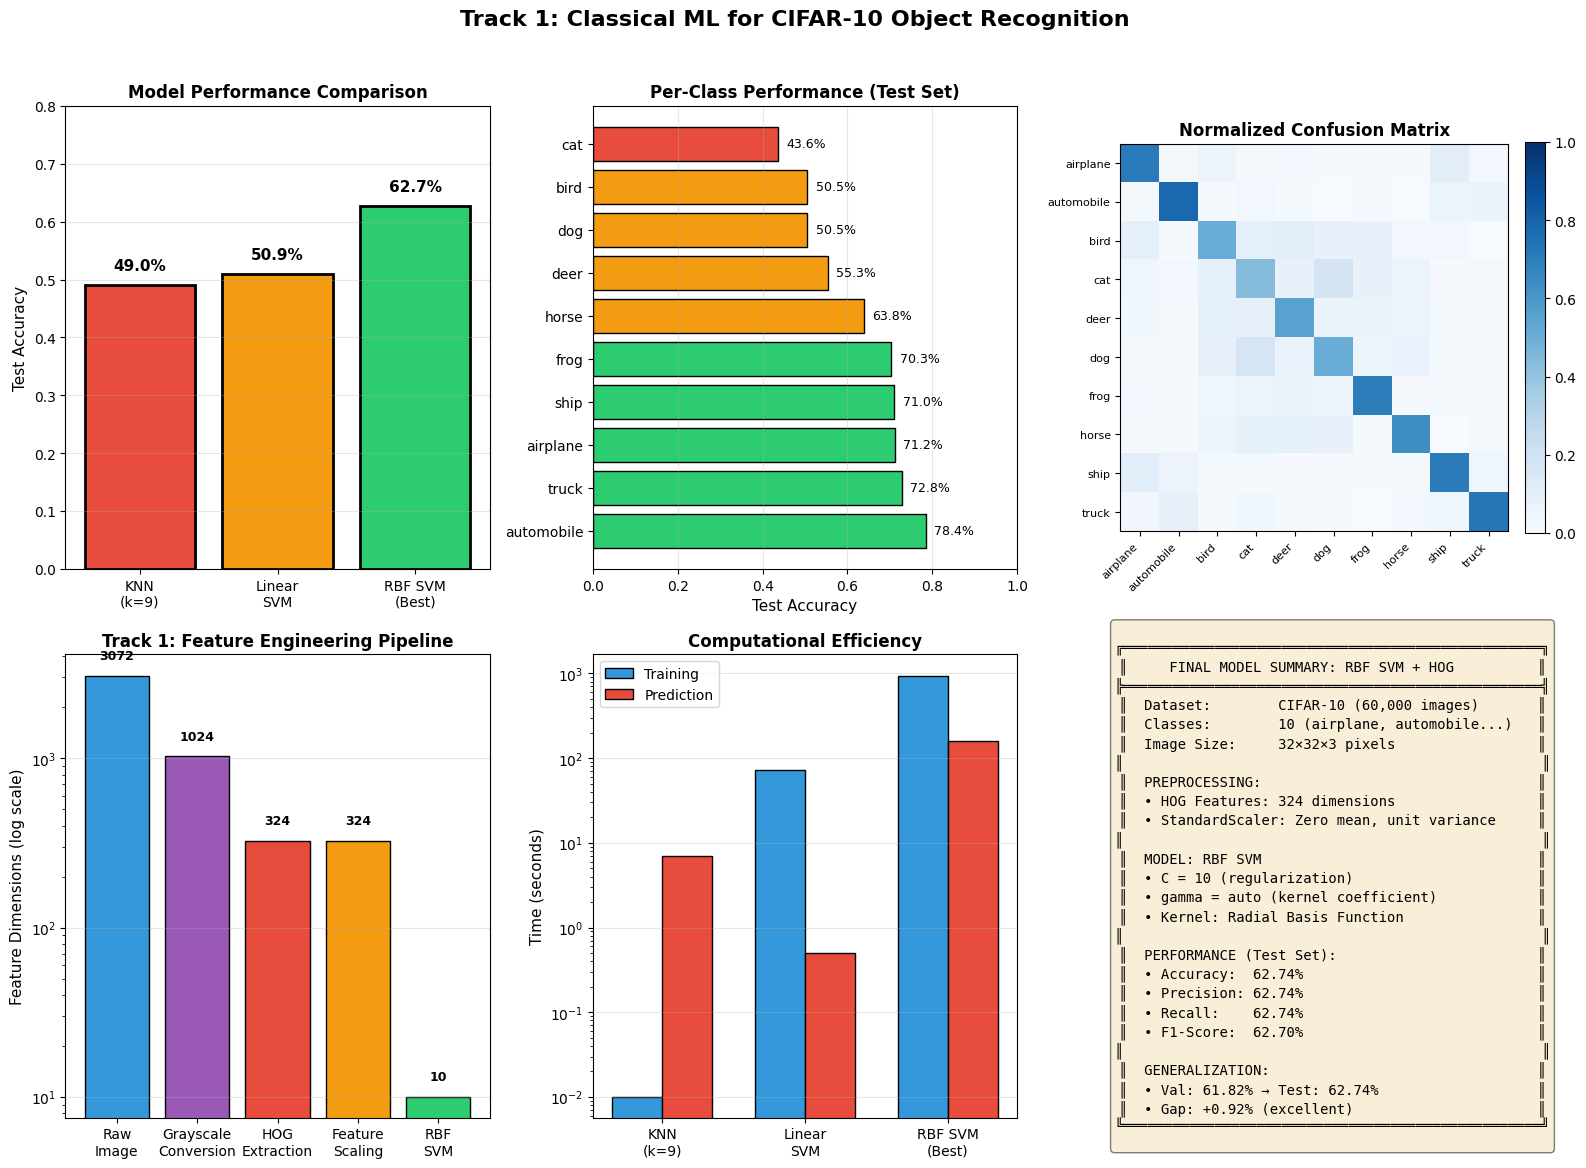


Visualization saved! This figure covers multiple assignment requirements:
✓ Model architecture and hyperparameters
✓ Performance metrics and confusion matrix
✓ Training strategy (time analysis)
✓ Feature engineering pipeline


In [9]:
# Create comprehensive visualization for your presentation
fig = plt.figure(figsize=(16, 12))

# 1. Model Comparison Bar Chart
ax1 = plt.subplot(2, 3, 1)
models = ['KNN\n(k=9)', 'Linear\nSVM', 'RBF SVM\n(Best)']
accuracies = [0.4902, 0.5088, 0.6274]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylim(0, 0.8)
ax1.set_ylabel('Test Accuracy', fontsize=11)
ax1.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Per-Class Accuracy (Test Set)
ax2 = plt.subplot(2, 3, 2)
sorted_indices = np.argsort(per_class_acc_test)[::-1]
sorted_names = [class_names[i] for i in sorted_indices]
sorted_acc = per_class_acc_test[sorted_indices]
colors_cls = ['#2ecc71' if a > 0.7 else '#f39c12' if a > 0.5 else '#e74c3c' for a in sorted_acc]
bars2 = ax2.barh(sorted_names, sorted_acc, color=colors_cls, edgecolor='black')
ax2.set_xlim(0, 1)
ax2.set_xlabel('Test Accuracy', fontsize=11)
ax2.set_title('Per-Class Performance (Test Set)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for bar, acc in zip(bars2, sorted_acc):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2.,
             f'{acc:.1%}', va='center', fontsize=9)

# 3. Confusion Matrix (simplified)
ax3 = plt.subplot(2, 3, 3)
cm_normalized = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
im = ax3.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
ax3.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
tick_marks = np.arange(len(class_names))
ax3.set_xticks(tick_marks)
ax3.set_yticks(tick_marks)
ax3.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax3.set_yticklabels(class_names, fontsize=8)

# 4. Feature Engineering Pipeline
ax4 = plt.subplot(2, 3, 4)
pipeline_stages = ['Raw\nImage', 'Grayscale\nConversion', 'HOG\nExtraction', 'Feature\nScaling', 'RBF\nSVM']
stage_sizes = [3072, 1024, 324, 324, 10]  # Approximate sizes
colors_pipe = ['#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#2ecc71']
bars4 = ax4.bar(pipeline_stages, stage_sizes, color=colors_pipe, edgecolor='black')
ax4.set_yscale('log')
ax4.set_ylabel('Feature Dimensions (log scale)', fontsize=11)
ax4.set_title('Track 1: Feature Engineering Pipeline', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar, size in zip(bars4, stage_sizes):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.2,
             f'{size}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Training Time Comparison
ax5 = plt.subplot(2, 3, 5)
train_times = [0.01, 71.44, 335.9 + 605.8]  # KNN, Linear, RBF (including tuning)
pred_times = [7.05, 0.5, 158.13]  # Approximate prediction times
x = np.arange(len(models))
width = 0.35
bars5a = ax5.bar(x - width/2, train_times, width, label='Training', color='#3498db', edgecolor='black')
bars5b = ax5.bar(x + width/2, pred_times, width, label='Prediction', color='#e74c3c', edgecolor='black')
ax5.set_ylabel('Time (seconds)', fontsize=11)
ax5.set_title('Computational Efficiency', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(models)
ax5.legend()
ax5.set_yscale('log')
ax5.grid(axis='y', alpha=0.3)

# 6. Key Metrics Summary Table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
╔══════════════════════════════════════════════════╗
║     FINAL MODEL SUMMARY: RBF SVM + HOG          ║
╠══════════════════════════════════════════════════╣
║  Dataset:        CIFAR-10 (60,000 images)       ║
║  Classes:        10 (airplane, automobile...)   ║
║  Image Size:     32×32×3 pixels                 ║
║                                                  ║
║  PREPROCESSING:                                 ║
║  • HOG Features: 324 dimensions                 ║
║  • StandardScaler: Zero mean, unit variance     ║
║                                                  ║
║  MODEL: RBF SVM                                 ║
║  • C = 10 (regularization)                      ║
║  • gamma = auto (kernel coefficient)            ║
║  • Kernel: Radial Basis Function                ║
║                                                  ║
║  PERFORMANCE (Test Set):                        ║
║  • Accuracy:  62.74%                            ║
║  • Precision: 62.74%                            ║
║  • Recall:    62.74%                            ║
║  • F1-Score:  62.70%                            ║
║                                                  ║
║  GENERALIZATION:                                ║
║  • Val: 61.82% → Test: 62.74%                   ║
║  • Gap: +0.92% (excellent)                      ║
╚══════════════════════════════════════════════════╝
"""
ax6.text(0.5, 0.5, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Track 1: Classical ML for CIFAR-10 Object Recognition', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nVisualization saved! This figure covers multiple assignment requirements:")
print("✓ Model architecture and hyperparameters")
print("✓ Performance metrics and confusion matrix")
print("✓ Training strategy (time analysis)")
print("✓ Feature engineering pipeline")